# The goal of this notebook is to model how the shade provided by the shade trees in the agroforestry system is at risk. Here we model the risk for two plots in the dominican rebublic.

## Let's attribute height, tree cover and land cover to the lat/lons that we have for the two agroforestries, we assume that they are square, and that the given lat/lon is the the center of the square

In [717]:
import rasterio
import numpy as np
from rasterio.windows import from_bounds

# === Paths to raster data ===
# 🌲 Canopy height: ETH Zurich Global Canopy Height dataset (10m)
# Download from: https://planetarycomputer.microsoft.com/dataset/global-forest-canopy-height
# Search: "ETH Global Canopy Height 2020"
paths = {
    "canopy_height": [
        "/Users/szelie/data/unu/canopy/ETH_GlobalCanopyHeight_10m_2020_N18W069_Map.tif",
        "/Users/szelie/data/unu/canopy/ETH_GlobalCanopyHeight_10m_2020_N18W072_Map.tif"
    ],

    # 🌳 Forest cover: Hansen Global Forest Change / Tree Cover (2000 baseline, updated annually)
    # Download from: https://earthenginepartners.appspot.com/science-2013-global-forest/download_v1.7.html
    # Look for: "treecover2000", or download via GEE
    "forest_cover": [
        "/Users/szelie/data/unu/tree_cover/20N_070W.tif",
        "/Users/szelie/data/unu/tree_cover/20N_080W.tif",
        "/Users/szelie/data/unu/tree_cover/20N_090W.tif"
    ],

    # 🌍 Land cover: ESA WorldCover 10m v2.0 (2021)
    # Download from: https://esa-worldcover.org/en
    # Navigate to "Download" > "WorldCover v200" > TIF (10m resolution)
    "land_cover": [
        "/Users/szelie/data/unu/WORLDCOVER/ESA_WORLDCOVER_10M_2021_V200/MAP/ESA_WorldCover_10m_2021_v200_N18W075_Map/ESA_WorldCover_10m_2021_v200_N18W075_Map.tif",
        "/Users/szelie/data/unu/WORLDCOVER/ESA_WORLDCOVER_10M_2021_V200/MAP/ESA_WorldCover_10m_2021_v200_N15W072_Map/ESA_WorldCover_10m_2021_v200_N15W072_Map.tif",
        "/Users/szelie/data/unu/WORLDCOVER/ESA_WORLDCOVER_10M_2021_V200/MAP/ESA_WorldCover_10m_2021_v200_N18W072_Map/ESA_WorldCover_10m_2021_v200_N18W072_Map.tif", 
        "/Users/szelie/data/unu/WORLDCOVER/ESA_WORLDCOVER_10M_2021_V200/MAP/ESA_WorldCover_10m_2021_v200_N18W069_Map.tif"
    ]
}



def meters_to_degrees(meters):
    """
    Approximate conversion from meters to degrees (latitude-wise).
    Works for small distances; for more precise results, use pyproj.
    """
    return meters / 111_000  # 1 degree ≈ 111 km

def extract_mean_raster_value_by_area(paths, lon, lat, plot_area_m2=4184):
    """
    Extract mean raster value from a square area centered at lat/lon.
    Area is in square meters (e.g., 4184 m²). Automatically converts to degrees.
    """
    side_m = np.sqrt(plot_area_m2)  # assume square plot
    buffer_deg = meters_to_degrees(side_m) / 2  # half side length in degrees

    for path in paths:
        try:
            with rasterio.open(path) as src:
                if src.bounds.left <= lon <= src.bounds.right and src.bounds.bottom <= lat <= src.bounds.top:
                    bounds = (
                        lon - buffer_deg,
                        lat - buffer_deg,
                        lon + buffer_deg,
                        lat + buffer_deg,
                    )
                    window = from_bounds(*bounds, transform=src.transform)
                    data = src.read(1, window=window, masked=True)
                    if data.count() > 0:
                        mean_val = data.mean()
                        return float(mean_val)
        except Exception:
            continue
    return np.nan

def get_plot_satellite_features(lon, lat, paths_dict, plot_area_m2=4184):
    return {
        "land_use_class": extract_mean_raster_value_by_area(paths_dict["land_cover"], lon, lat, plot_area_m2),
        "canopy_height": extract_mean_raster_value_by_area(paths_dict["canopy_height"], lon, lat, plot_area_m2),
        "forest_cover": extract_mean_raster_value_by_area(paths_dict["forest_cover"], lon, lat, plot_area_m2)
    }


In [718]:
import random

#in case we would not have the size
plot_size_distribution = [
    (300, 800),
    (800, 1200),
    (1200, 1800),
    (1800, 2500),
]

def sample_plot_size(dist):
    # Randomly pick one of the intervals, then sample uniformly from it
    lower, upper = random.choice(dist)
    return random.uniform(lower, upper)

# Add known sizes for the first two
points_data = [
    {"lon": -71.252111, "lat": 19.293583, "plot_area_m2": 4184},
    {"lon": -71.293917, "lat": 19.308333, "plot_area_m2": 8000},
    #{"lon": -70.62000,  "lat": 18.98000, "plot_area_m2": None},  # Will be sampled
]

# Create GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    points_data,
    geometry=[Point(p["lon"], p["lat"]) for p in points_data],
    crs="EPSG:4326"
)

land_cover_lookup = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    # Extend if needed
}

results = []

for idx, row in gdf_points.iterrows():
    lat = row["lat"]
    lon = row["lon"]
    plot_area = row["plot_area_m2"]
    print(plot_area)
    if pd.isna(plot_area):
        plot_area = sample_plot_size(plot_size_distribution)

    #try:
    features = get_plot_satellite_features(lon, lat, paths, plot_area_m2=plot_area)
    features["land_use_class"] = land_cover_lookup.get(features["land_use_class"], "Unknown")
    features["lon"] = lon
    features["lat"] = lat
    features["plot_area_m2"] = plot_area
    results.append(features)
    #except Exception as e:
    #    print(f"⚠️ Failed to process point at ({lat}, {lon}): {e}")

# Create final DataFrame
import pandas as pd
df_results = pd.DataFrame(results)


4184
8000


## --> so now we have the maximum height of the canopy, the forest cover, as well as the land use class:

In [719]:
df_results

,land_use_class,canopy_height,forest_cover,lon,lat,plot_area_m2
0,Tree cover,19.857143,93.000000,-71.252111,19.293583,4184
1,Tree cover,23.550000,81.333333,-71.293917,19.308333,8000


In [720]:
def classify_agroforestry(row):
    """
    Classify a plot as likely agroforestry, sun-grown, or unclear based on satellite-derived features.

    Parameters:
    - row: A pandas Series with the following expected columns:
        - 'canopy_height' (float): average height of vegetation in meters
        - 'forest_cover' (float): percent forest cover (0–100)
        - 'land_use_class' (str): categorical land cover class (e.g. 'Tree cover', 'Cropland', etc.)

    Returns:
    - A string classification: 
        - 'Likely agroforestry'
        - 'Likely sun-grown'
        - 'Mixed or unclear'
        - 'Unknown' (if any required value is missing)
    """
    if pd.isna(row["canopy_height"]) or pd.isna(row["forest_cover"]) or pd.isna(row["land_use_class"]):
        return "Unknown"
    
    if row["canopy_height"] >= 6 and row["forest_cover"] >= 50 and row["land_use_class"] in ["Tree cover", "Cropland"]:
        return "Likely agroforestry"
    
    if row["canopy_height"] < 3 and row["forest_cover"] < 30 and row["land_use_class"] in ["Grassland", "Built-up"]:
        return "Likely sun-grown"
    
    return "Mixed or unclear"



In [721]:
df_results["agroforestry_class"] = df_results.apply(classify_agroforestry, axis=1)


In [722]:
df_results["geometry"] = df_results.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)


# Now, we have two agroforestry systems for which we know the composition, let's load the data

In [723]:
agroforest = {}
agroforest[0] = pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/aguacate_vegetation.csv")
agroforest[1]  = pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/piso_verde_vegetation.csv")

In [724]:
agroforest[0]

,species,type,height_m,cover_ratio,quantity
0,Inga fagifolia single,1st tree,20,20.0,43
1,Mangifera indica single,1st tree,20,5.0,22
2,Roystonea hispaniolana single,1st tree,20,1.0,6
3,Didymopanax morototoni single,1st tree,20,1.0,5
4,Senna spectabilis single,1st tree,20,0.5,2
5,Musa × paradisiaca,2nd tree,10,35.0,52
6,Theobroma cacao,2nd tree,10,20.0,45
7,Citrus × sinensis single,2nd tree,10,2.5,11
8,Citrus × aurantium single,2nd tree,10,2.5,10
9,Pimenta racemosa single,2nd tree,10,2.0,8


In [725]:
import geopandas as gpd
import folium
from shapely.geometry import Point

# Define your GeoDataFrame (already created)
# gdf_latlon = df_results  # assuming df_results has 'geometry' and relevant columns

# Define colour map
color_map = {
    "Likely agroforestry": "green",
    "Likely sun-grown": "orange",
    "Mixed or unclear": "purple",
    "Unknown": "gray"
}

# Center map (e.g. on the first point)
center = [
    gdf_latlon.geometry.apply(lambda p: p.y).mean(),
    gdf_latlon.geometry.apply(lambda p: p.x).mean()]
m = folium.Map(location=center, zoom_start=12, tiles=None)

# Add satellite basemap
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Esri Satellite",
    overlay=False,
    control=True
).add_to(m)

# Add each point as a CircleMarker
for _, row in gdf_latlon.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color=color_map.get(row.get("agroforestry_class", "Unknown"), "black"),
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(f"""
            <b>Canopy height:</b> {row.get('canopy_height', 'n/a')} m<br>
            <b>Forest cover:</b> {row.get('forest_cover', 'n/a')} %<br>
            <b>Land use:</b> {row.get('land_use_class', 'n/a')}<br>
            <b>Type:</b> {row.get('agroforestry_class', 'n/a')}
        """, max_width=250)
    ).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Show the map
m


# the following sell is a function to make an agroforestry plot. basically you can either give the number of trees of each species or give a probability of each species occurence. It would then estimate which trees could be there. Not sure if this is useful  

### ☂️ Estimating Shading Contribution per Species

The core objective of this function is to estimate how much **shading** each tree species contributes within a simulated agroforestry plot.

---

#### **Step-by-Step Shading Estimation**

1. **Adjusted Cover Ratio**

   For each species, we calculate an adjusted cover ratio based on how many individuals are present:

   \[
   \text{adjusted\_cover\_ratio} = \text{cover\_ratio} \times \text{n\_trees}
   \]

   - This gives the total percent of the plot that would be covered by that species if all trees contributed equally.

2. **Simulated Cover Area (per species)**

   Then, for each species:

   \[
   \text{adjusted\_cover\_area (m²)} = \left( \frac{\text{adjusted\_cover\_ratio}}{100} \right) \times \text{plot\_size\_m2}
   \]

   - This is the raw estimated area each species would cover based on its number of trees and cover ratio.

3. **Total Simulated Cover Area**

   We sum the adjusted cover areas of all species to get:

   \[
   \text{total\_simulated\_cover\_area} = \sum \text{adjusted\_cover\_area}
   \]

4. **Observed Forest Cover from Satellite**

   A reference cover area is computed from the satellite-derived forest cover percentage:

   \[
   \text{satellite\_forest\_area} = \left( \frac{\text{forest\_cover}}{100} \right) \times \text{plot\_size\_m2}
   \]

5. **Final Scaled Shading per Species**

   To ensure realism, each species’ simulated cover area is **scaled** so that the total matches the observed forest cover:

   \[
   \text{shading\_m2 (per species)} = \left( \frac{\text{adjusted\_cover\_area}}{\text{total\_simulated\_cover\_area}} \right) \times \text{satellite\_forest\_area}
   \]

   - This allocates the observed forest cover proportionally among species based on their simulated cover contributions.

---


This scaling approach:

- Ensures consistency with observed land cover data.
- Allows attributing **forest structure and ecosystem function** (like shade) to specific species.
- Enables comparisons across sites with different satellite-observed canopy levels.

The output column `shading_m2` in the final GeoDataFrame contains this final **per-species shading estimate**.



In [818]:
import pandas as pd
import geopandas as gpd
import numpy as np
import random
from shapely import wkt

def simulate_agroforestry_plot(
    row,
    plot_size_m2=None,
    species_df=None,
    plot_size_distribution=[(300, 800), (800, 1200), (1200, 1800), (1800, 2500)],
    plot_size_weights=[0.3, 0.4, 0.2, 0.1]
):
    """
    Simulates an agroforestry plot composition based on provided species characteristics
    and environmental metadata.

    Parameters:
        row: A GeoDataFrame row with geometry and satellite-derived columns: forest_cover, canopy_height, land_use_class.
        plot_size_m2: Optional fixed plot size. If None, a random one is selected based on a distribution.
        species_df: DataFrame with columns like 'species', 'height_m', 'type', 'cover_ratio', 'quantity' or 'probability'.
        plot_size_distribution: List of (min, max) tuples for random plot size sampling.
        plot_size_weights: Probabilities for each range.

    Returns:
        GeoDataFrame with one row per species in the simulated plot, including shading estimates.
    """

    geometry = wkt.loads(str(row.geometry))
    forest_cover = row.get("forest_cover", 0)
    canopy_height = row.get("canopy_height", None)
    land_use_class = row.get("land_use_class", "Unknown")

    # --- Prepare species input ---
    counts, heights, types, cover_ratios = {}, {}, {}, {}
    if species_df is not None and not species_df.empty:
        for _, row_species in species_df.iterrows():
            species = row_species["species"]
            height = row_species.get("height_m", 10)
            type_ = row_species.get("type", "")
            cover_ratio = row_species.get("cover_ratio", None)

            if pd.notnull(row_species.get("quantity", None)):
                n = int(row_species["quantity"])
            elif pd.notnull(row_species.get("probability", None)):
                if np.random.rand() < row_species["probability"]:
                    n = np.random.randint(1, 6)
                else:
                    continue
            else:
                continue  # skip if neither quantity nor probability is defined

            counts[species] = counts.get(species, 0) + n
            heights[species] = height
            types[species] = type_
            cover_ratios[species] = cover_ratio if pd.notnull(cover_ratio) else 1.5 * height  # simple fallback

    if not counts:
        return None

    # --- Determine plot size ---
    if plot_size_m2 is None:
        r = random.choices(plot_size_distribution, weights=plot_size_weights)[0]
        plot_size_m2 = random.randint(r[0], r[1])

    # --- Classify tree role ---
    def infer_role(h):
        if h >= 15:
            return "upper canopy"
        elif h >= 5:
            return "mid canopy"
        else:
            return "understory"

    # --- Build output ---
    output_dict = {
        "species": list(counts.keys()),
        "n_trees": [counts[s] for s in counts.keys()],
        "height_m": [heights[s] for s in counts.keys()],
        "type": [types[s] for s in counts.keys()],
        "cover_ratio": [cover_ratios[s] for s in counts.keys()],
        "role": [infer_role(heights[s]) for s in counts.keys()],
        "plot_size_m2": [plot_size_m2] * len(counts),
        "forest_cover": [forest_cover] * len(counts),
        "canopy_height": [canopy_height] * len(counts),
        "land_use_class": [land_use_class] * len(counts),
        "system_type": ["Agroforestry"] * len(counts),
        "source": ["table"] * len(counts)
    }

    gdf = gpd.GeoDataFrame(output_dict, geometry=[geometry] * len(counts), crs="EPSG:4326")

    # --- Calculate shading ---
    gdf["adjusted_cover_ratio"] = gdf["cover_ratio"] * gdf["n_trees"]
    gdf["adjusted_cover_area_m2"] = (gdf["adjusted_cover_ratio"] / 100) * gdf["plot_size_m2"]
    gdf["species_based_cover_area_m2"] = gdf["adjusted_cover_area_m2"]

    # --- Estimate realistic forest-covered area ---
    total_simulated_cover_area = gdf["adjusted_cover_area_m2"].sum()
    satellite_forest_area = (forest_cover / 100) * plot_size_m2
    estimated_forest_cover_area = min(total_simulated_cover_area, satellite_forest_area)

    gdf["estimated_forest_cover_area_m2"] = estimated_forest_cover_area
    gdf["expected_forest_area_m2"] = satellite_forest_area

    # --- Estimate shading contribution per species (scaled) ---
    if total_simulated_cover_area > 0:
        gdf["shading_m2"] = (gdf["adjusted_cover_area_m2"] / total_simulated_cover_area) * estimated_forest_cover_area
    else:
        gdf["shading_m2"] = 0

    return gdf


In [947]:
agroforest[1]

,species,type,height_m,cover_ratio,quantity
0,Soymida febrifuga,1st tree,20,1.0,3
1,Roystonea hispaniolana,1st tree,20,1.0,3
2,Simarouba glauca,1st tree,20,0.5,1
3,Pinus occidentalis,1st tree,20,0.5,1
4,Cecropia schreberiana,1st tree,20,0.5,1
5,Musa × paradisiaca,2nd tree,10,5.0,15
6,Cajanus cajan,2nd tree,10,1.0,7
7,Anacardium occidentale,2nd tree,10,1.0,6
8,Simarouba glauca,2nd tree,10,0.5,3
9,Citrus × sinensis,2nd tree,10,0.5,3


below, we run the simulate_agroforest for each plot and concatenate it

In [902]:
# Run simulations for each row
simulated_results = []
for idx, row in df_results.iterrows():
    species_df = agroforest[idx]  # match by row index
    result_df = simulate_agroforestry_plot(row, row.plot_area_m2, species_df)
    if result_df is not None:
        result_df["plot_index"] = idx
        simulated_results.append(result_df)

# Combine results
agroforest_df = pd.concat(simulated_results, ignore_index=True)


In [905]:
agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
].shading_m2.sum()

41.33627209473183

# plotting shading contribution:

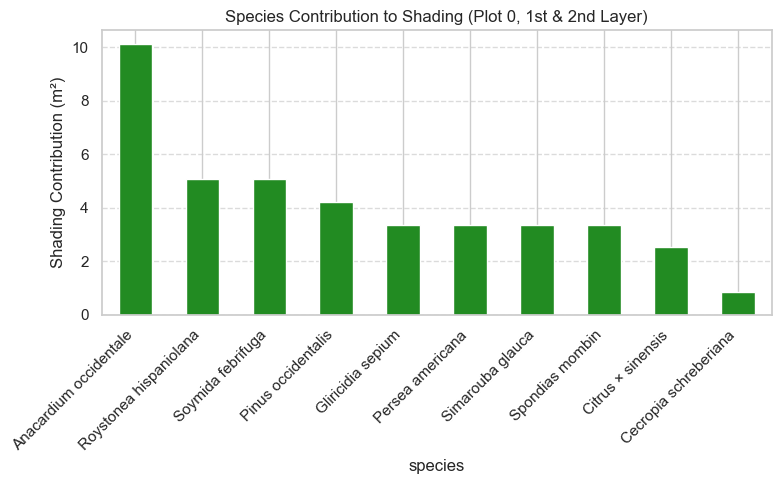

In [822]:
import matplotlib.pyplot as plt

# Filter to first and second layer trees in plot 0
subset = agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
]

# Group by species and sum shading_m2
shading_contrib = (
    subset.groupby("species")["shading_m2"]
    .sum()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(8, 5))
shading_contrib.plot(kind="bar", color="forestgreen")
plt.ylabel("Shading Contribution (m²)")
plt.title("Species Contribution to Shading (Plot 0, 1st & 2nd Layer)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [945]:
agroforest_df[
    (agroforest_df["plot_index"] == 1)]

,species,n_trees,height_m,type,cover_ratio,role,plot_size_m2,forest_cover,canopy_height,land_use_class,...,RMAX,PHOTO,KTMPR,KTMP,CLIZ,DRA,DRAR,impf_TM,impf_PR,value
25,Soymida febrifuga,3,20,1st tree,1.0,upper canopy,8000,81.333333,23.55,Tree cover,...,1500.0,short day (<12 hours),NaN,NaN,tropical wet & dry (Aw),well (dry spells),"poorly (saturated >50% of year), well (dry spe...",9,10,5.061584
26,Roystonea hispaniolana,3,20,1st tree,1.0,upper canopy,8000,81.333333,23.55,Tree cover,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,12,5.061584
27,Simarouba glauca,4,10,2nd tree,0.5,mid canopy,8000,81.333333,23.55,Tree cover,...,4000.0,NaN,NaN,NaN,"tropical wet & dry (Aw), tropical wet (Ar)",well (dry spells),"well (dry spells), excessive (dry/moderately dry)",13,14,3.374390
28,Pinus occidentalis,5,10,2nd tree,0.5,mid canopy,8000,81.333333,23.55,Tree cover,...,1600.0,"short day (<12 hours), neutral day (12-14 hour...",NaN,NaN,tropical wet & dry (Aw),well (dry spells),"poorly (saturated >50% of year), well (dry spe...",15,16,4.217987
29,Cecropia schreberiana,1,20,1st tree,0.5,upper canopy,8000,81.333333,23.55,Tree cover,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,12,0.843597
30,Musa × paradisiaca,55,4,Shrub,20.0,understory,8000,81.333333,23.55,Tree cover,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1855.914257
31,Cajanus cajan,11,4,Shrub,0.5,understory,8000,81.333333,23.55,Tree cover,...,4000.0,"short day (<12 hours), neutral day (12-14 hours)",NaN,NaN,"tropical wet & dry (Aw), tropical wet (Ar), st...",well (dry spells),"well (dry spells), excessive (dry/moderately dry)",7,8,9.279571
32,Anacardium occidentale,6,10,2nd tree,1.0,mid canopy,8000,81.333333,23.55,Tree cover,...,4000.0,"short day (<12 hours), neutral day (12-14 hour...",NaN,NaN,"tropical wet & dry (Aw), steppe or semiarid (B...",well (dry spells),"well (dry spells), excessive (dry/moderately dry)",17,18,10.123169
33,Citrus × sinensis,3,10,2nd tree,0.5,mid canopy,8000,81.333333,23.55,Tree cover,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,12,2.530792
34,Guazuma ulmifolia,8,4,Shrub,0.5,understory,8000,81.333333,23.55,Tree cover,...,1700.0,short day (<12 hours),NaN,NaN,"tropical wet & dry (Aw), tropical wet (Ar)",well (dry spells),well (dry spells),19,20,6.748779


# load ecocrop, downloaded from here: https://github.com/OpenCLIM/ecocrop
find value per specie

In [919]:
import pandas as pd

# Load EcoCrop database
ecocrop = pd.read_csv("/Users/szelie/data/unu/EcoCrop_DB.csv", encoding="latin1")

# Clean EcoCrop species names
ecocrop["species_clean"] = ecocrop["ScientificName"].str.strip().str.lower()

# Select relevant climate and drought-related columns
climate_cols = [
    "species_clean",
    "TMIN", "TOPMN", "TOPMX", "TMAX",        # Temperature thresholds (°C)
    "RMIN", "ROPMN", "ROPMX", "RMAX",        # Precipitation thresholds (mm)
    "PHOTO",                                 # Photoperiod (hours)
    "KTMPR", "KTMP",                         # Temperature stress
    "CLIZ",                                  # Climatic zone
    "DRA", "DRAR"                            # Drought tolerance and its reliability
]
ecocrop_subset = ecocrop[climate_cols]

# Clean species names in agroforest DataFrame
agroforest_df["species_clean"] = agroforest_df["species"].str.strip().str.lower()

# Merge with EcoCrop data
agroforest_df = agroforest_df.merge(
    ecocrop_subset,
    on="species_clean",
    how="left"
)


In [920]:
import matplotlib.pyplot as plt

def plot_agroforest_vulnerability_with_spei(df, spei_dict):
    """
    Visualises the climate vulnerability of agroforestry shade tree species 
    by comparing their ideal and tolerable ranges for temperature, precipitation, 
    and drought conditions.

    The plot contains three horizontal bar charts:
    1. Temperature (°C): Ideal and tolerable temperature range per species.
    2. Precipitation (mm/month): Ideal and tolerable precipitation range per species.
    3. Drought Tolerance (SPEI): Ideal and tolerable drought tolerance expressed as 
       a range of Standardised Precipitation-Evapotranspiration Index (SPEI) values.

    Parameters:
    ----------
    df : pandas.DataFrame
        DataFrame containing at least the following columns:
        - 'species': species name
        - 'type': must include "1st tree" or "2nd tree" for shade trees
        - 'TOPMN', 'TOPMX': ideal temperature min and max
        - 'TMIN', 'TMAX': tolerable temperature min and max
        - 'ROPMN', 'ROPMX': ideal precipitation min and max
        - 'RMIN', 'RMAX': tolerable precipitation min and max

    spei_dict : dict
        Dictionary mapping species names to their drought tolerance ranges. 
        Format:
        {
            "Species A": {
                "ideal": (min_spei, max_spei),
                "tolerable": (min_spei, max_spei)
            },
            ...
        }

    Returns:
    -------
    None
        Displays a matplotlib figure with three subplots showing climate vulnerability.
    """

    shade_df = df[df["type"].isin(["1st tree", "2nd tree"])].copy()
    species_order = list(shade_df["species"].value_counts().index)

    fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    # === 1. Temperature ===
    temp_df = (
        shade_df.groupby("species")[["TOPMN", "TOPMX", "TMIN", "TMAX"]]
        .mean(numeric_only=True)
        .dropna()
        .reindex(species_order)
    )
    for i, row in temp_df.iterrows():
        axs[0].barh(i, row["TOPMX"] - row["TOPMN"], left=row["TOPMN"], color="#ffcc99", edgecolor="black", label="Ideal" if i == temp_df.index[0] else "")
        axs[0].barh(i, row["TMAX"] - row["TMIN"], left=row["TMIN"], color="#ffe6cc", edgecolor="black", alpha=0.5, label="Tolerable" if i == temp_df.index[0] else "")
    axs[0].set_title("Temperature (°C)")
    axs[0].set_xlabel("°C")

    # === 2. Precipitation ===
    prec_df = (
        shade_df.groupby("species")[["ROPMN", "ROPMX", "RMIN", "RMAX"]]
        .mean(numeric_only=True)
        .dropna()
        .reindex(species_order)
    )
    for i, row in prec_df.iterrows():
        axs[1].barh(i, row["ROPMX"] - row["ROPMN"], left=row["ROPMN"], color="#99ccff", edgecolor="black", label="Ideal" if i == prec_df.index[0] else "")
        axs[1].barh(i, row["RMAX"] - row["RMIN"], left=row["RMIN"], color="#cce6ff", edgecolor="black", alpha=0.5, label="Tolerable" if i == prec_df.index[0] else "")
    axs[1].set_title("Precipitation (mm/month)")
    axs[1].set_xlabel("mm")

    # === 3. Drought Tolerance (SPEI) ===
    for i, species in enumerate(species_order):
        if species in spei_dict:
            ideal = spei_dict[species]["ideal"]
            tolerable = spei_dict[species]["tolerable"]

            # Only plot negative parts
            ideal_start = max(ideal[0], -2)
            ideal_end = min(ideal[1], 0)
            tolerable_start = max(tolerable[0], -2.5)
            tolerable_end = min(tolerable[1], 0)

            axs[2].barh(species, ideal_end - ideal_start, left=ideal_start, color="#a1dab4", edgecolor="black", label="Ideal" if i == 0 else "")
            axs[2].barh(species, tolerable_end - tolerable_start, left=tolerable_start, color="#e5f5f9", edgecolor="black", alpha=0.5, label="Tolerable" if i == 0 else "")
    axs[2].set_title("Drought Tolerance (SPEI)")
    axs[2].set_xlabel("SPEI (drought ≤ 0)")
    axs[2].set_xlim(-2.5, 0)

    # === Styling ===
    for ax in axs:
        ax.invert_yaxis()
        ax.legend()
        ax.grid(True, axis="x", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


In [887]:
def generate_spei_dict_from_dra(df):
    """
    Generate a dictionary of drought tolerance thresholds (SPEI) for each species 
    based on qualitative drought resistance descriptions.

    This function interprets values in the 'DRA' column (drought resistance assessment)
    and maps them to quantitative SPEI (Standardised Precipitation-Evapotranspiration Index)
    ranges indicating:
    - "ideal": range where the species performs best
    - "tolerable": wider range where the species can survive but may be stressed

    DRA labels are matched using keyword-based mapping to predefined SPEI ranges.

    Parameters:
    ----------
    df : pandas.DataFrame
        Input dataframe with at least the following columns:
        - 'species': Name of the tree species
        - 'DRA': Drought resistance description (e.g., "moderate", "very poor")

    Returns:
    -------
    spei_dict : dict
        Dictionary where keys are species names and values are SPEI tolerance ranges:
        {
            "Species A": {
                "ideal": (min_spei, max_spei),
                "tolerable": (min_spei, max_spei)
            },
            ...
        }

    Notes:
    -----
    - Species with no recognizable DRA description are omitted.
    - If multiple labels are present for a species, the most drought-tolerant match is used.
    """

    # Define drought tolerance categories and their SPEI thresholds
    dra_map = {
        "very poor": {"ideal": (-0.2, 0), "tolerable": (-0.5, 0)},
        "poor": {"ideal": (-0.3, 0), "tolerable": (-0.7, 0)},
        "moderate": {"ideal": (-0.5, 0), "tolerable": (-1.0, 0)},
        "well (dry spells)": {"ideal": (-0.7, 0), "tolerable": (-1.5, 0)},
        "excessive": {"ideal": (-1.0, 0), "tolerable": (-2.0, 0)},
    }

    # Create a ranked list for determining the "most tolerant"
    tolerance_rank = list(dra_map.keys())[::-1]  # Most tolerant first

    spei_dict = {}
    for species, group in df.groupby("species"):
        dra_values = group["DRA"].dropna().astype(str).str.lower().unique()
        matched_keys = set()
        for val in dra_values:
            for key in dra_map:
                if key in val:
                    matched_keys.add(key)

        # Select the most tolerant matching description
        for key in tolerance_rank:
            if key in matched_keys:
                spei_dict[species] = dra_map[key]
                break

    return spei_dict


In [871]:
agroforest_df[
    (agroforest_df["plot_index"] == 1) & (agroforest_df["type"].isin(["1st tree", "2nd tree"]))]

,species,n_trees,height_m,type,cover_ratio,role,plot_size_m2,forest_cover,canopy_height,land_use_class,...,RMIN,ROPMN,ROPMX,RMAX,PHOTO,KTMPR,KTMP,CLIZ,DRA,DRAR
25,Soymida febrifuga,3,20,1st tree,1.0,upper canopy,8000,81.333333,23.55,Tree cover,...,600.0,800.0,1300.0,1500.0,short day (<12 hours),NaN,NaN,tropical wet & dry (Aw),well (dry spells),"poorly (saturated >50% of year), well (dry spe..."
26,Roystonea hispaniolana,3,20,1st tree,1.0,upper canopy,8000,81.333333,23.55,Tree cover,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,Simarouba glauca,4,10,2nd tree,0.5,mid canopy,8000,81.333333,23.55,Tree cover,...,1200.0,2000.0,3000.0,4000.0,NaN,NaN,NaN,"tropical wet & dry (Aw), tropical wet (Ar)",well (dry spells),"well (dry spells), excessive (dry/moderately dry)"
28,Pinus occidentalis,5,10,2nd tree,0.5,mid canopy,8000,81.333333,23.55,Tree cover,...,1300.0,1400.0,1500.0,1600.0,"short day (<12 hours), neutral day (12-14 hour...",NaN,NaN,tropical wet & dry (Aw),well (dry spells),"poorly (saturated >50% of year), well (dry spe..."
29,Cecropia schreberiana,1,20,1st tree,0.5,upper canopy,8000,81.333333,23.55,Tree cover,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,Anacardium occidentale,6,10,2nd tree,1.0,mid canopy,8000,81.333333,23.55,Tree cover,...,400.0,750.0,1600.0,4000.0,"short day (<12 hours), neutral day (12-14 hour...",NaN,NaN,"tropical wet & dry (Aw), steppe or semiarid (B...",well (dry spells),"well (dry spells), excessive (dry/moderately dry)"
33,Citrus × sinensis,3,10,2nd tree,0.5,mid canopy,8000,81.333333,23.55,Tree cover,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,Spondias mombin,4,10,2nd tree,0.5,mid canopy,8000,81.333333,23.55,Tree cover,...,600.0,1000.0,2000.0,2800.0,"short day (<12 hours), neutral day (12-14 hour...",NaN,NaN,"tropical wet & dry (Aw), tropical wet (Ar)",well (dry spells),well (dry spells)
36,Persea americana,4,10,2nd tree,0.5,mid canopy,8000,81.333333,23.55,Tree cover,...,300.0,500.0,2000.0,2500.0,NaN,-4.0,-1.0,"tropical wet & dry (Aw), tropical wet (Ar)",well (dry spells),well (dry spells)
37,Gliricidia sepium,4,10,2nd tree,0.5,mid canopy,8000,81.333333,23.55,Tree cover,...,600.0,1200.0,2300.0,3500.0,short day (<12 hours),-2.0,-1.0,"tropical wet & dry (Aw), tropical wet (Ar)","well (dry spells), excessive (dry/moderately dry)","poorly (saturated >50% of year), well (dry spe..."


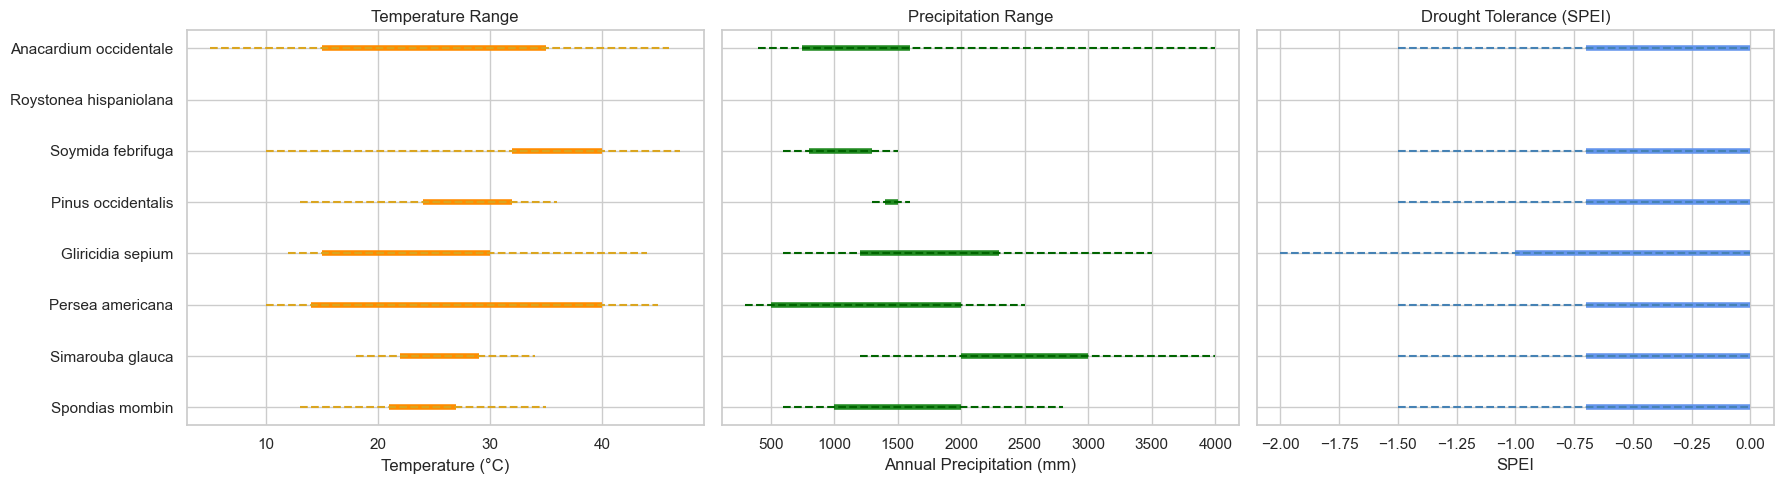

In [873]:
spei_dict = generate_spei_dict_from_dra(agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
])
plot_agroforest_vulnerability(agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
], spei_dict)

### 🔥🌧️ Generating Synthetic Climate Hazards for the Dominican Republic (DR)

This following cell builds synthetic 100-year hazard datasets for **heat (temperature)** and **drought (precipitation)** using the **TerraClimate** dataset and the **CLIMADA** hazard modeling framework. It performs the following steps:

---

#### 1. **Setup and Dataset Paths**
- Two climate scenarios are used:
  - `"historical"`: Historical climate data.
  - `"plus2C"`: Future climate scenario with +2°C warming.
- Files are cropped to the **Dominican Republic** using latitude and longitude bounds.

---

#### 2. **Annual Aggregation**
- Function: `get_annual_aggregates(path)`
  - Loads annual maxima of:
    - `tmin`: daily minimum temperature
    - `tmax`: daily maximum temperature
  - Computes annual max of mean temperature:  
    \[
    t_{\text{mean}} = \frac{t_{\text{max}} + t_{\text{min}}}{2}
    \]
  - Computes annual total **precipitation**.
  - Clips all outputs to DR extent.

---

#### 3. **Extreme Value Sampling (GEV)**
- Function: `generate_gev_sample_field(dataarray, n_years=100)`
  - Fits a **Generalized Extreme Value (GEV)** distribution at each grid point.
  - Draws 100 synthetic samples per pixel to simulate extreme future events.
  - If `invert=True`, the distribution is mirrored (used for **low precipitation** extremes).

---

#### 4. **Hazard Object Creation**
- Function: `create_hazard_from_array(...)`
  - Converts the synthetic yearly fields into **CLIMADA-compatible Hazard objects**.
  - Hazard type:
    - `"TM"` for temperature (`degC`)
    - `"PR"` for precipitation (`mm`)
  - Each year is treated as a separate event.
  - Includes:
    - `intensity` matrix (year × location)
    - `centroids` grid
    - event metadata (IDs, names, dates, frequency)

---

#### 5. **Run Full Pipeline**
- For each scenario:
  - Aggregates the raw climate data.
  - Samples 100 synthetic years for both temperature and precipitation.
  - Builds and stores the corresponding Hazard objects in a dictionary.

```python
hazard_dict = {
    "historical": {
        "TM": Hazard object for temperature,
        "PR": Hazard object for precipitation
    },
    "plus2C": {
        "TM": ...,
        "PR": ...
    }
}


In [731]:
import os
import glob
import xarray as xr
import numpy as np
from climada.hazard import Hazard, Centroids
from climada.util.constants import DEF_CRS
from scipy import sparse
from scipy.stats import genextreme

# Paths to TerraClimate data (cropped to DR)
paths = {
    "plus2C": "/Users/szelie/data/unu/terra_climate_scenarios_2c",
    "historical": "/Users/szelie/data/unu/terra_climate/",
}

# DR bounding box
LAT_BOUNDS_DR = (20.0, 17.5)
LON_BOUNDS_DR = (-72.0, -68.0)

def clip_to_dominican_republic(ds):
    return ds.sel(
        lat=slice(*LAT_BOUNDS_DR),
        lon=slice(*LON_BOUNDS_DR)
    )

# === Load and calculate annual max tmean + annual sum ppt ===
def get_annual_aggregates(path):
    def _load(varname, agg):
        files = sorted(glob.glob(os.path.join(path, f"TerraClimate*_{varname}_*_CA.nc")))
        print(f"📂 Loading {len(files)} files for {varname} from {path}")
        data = xr.concat([xr.open_dataset(f)[varname] for f in files], dim="time")
        grouped = data.groupby("time.year")
        return grouped.max(dim="time") if agg == "max" else grouped.sum(dim="time")

    tmin = _load("tmin", "max")  # annual max of daily min temp
    tmax = _load("tmax", "max")  # annual max of daily max temp
    tmean = (tmin + tmax) / 2    # estimated annual max of mean temp
    ppt = _load("ppt", "sum")    # annual total precipitation

    return clip_to_dominican_republic(tmean), clip_to_dominican_republic(ppt)

# === Fit GEV per pixel and sample 100 years ===
def generate_gev_sample_field(dataarray, n_years=100, start_year=2101, invert=False):
    synthetic_years = np.arange(start_year, start_year + n_years)

    def _fit_and_sample(ts):
        try:
            ts = -ts if invert else ts
            shape, loc, scale = genextreme.fit(ts)
            sampled = genextreme.rvs(shape, loc=loc, scale=scale, size=n_years)
            return -sampled if invert else sampled
        except Exception:
            return np.full(n_years, np.nan)

    lat = dataarray.lat
    lon = dataarray.lon
    stacked = dataarray.stack(grid=("lat", "lon"))

    sampled_values = np.array([
        _fit_and_sample(stacked.isel(grid=i).values)
        for i in range(stacked.sizes["grid"])
    ])

    reshaped = sampled_values.reshape((dataarray.sizes["lat"], dataarray.sizes["lon"], n_years))
    reshaped = np.transpose(reshaped, (2, 0, 1))  # year, lat, lon

    return xr.DataArray(
        reshaped,
        coords={"year": synthetic_years, "lat": lat, "lon": lon},
        dims=["year", "lat", "lon"]
    )

# === Build multi-year Hazard object from xarray ===
def create_hazard_from_array(dataarray, haz_type, units, start_year=2101):
    years = np.arange(start_year, start_year + dataarray.sizes["year"])
    lat_vals = dataarray.lat.values
    lon_vals = dataarray.lon.values
    lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
    n_cells = lat_grid.size

    intensity_data = np.vstack([
        dataarray.sel(year=yr).values.reshape(1, -1)
        for yr in dataarray.year.values
    ])
    intensity_data = np.nan_to_num(intensity_data, nan=0)

    intensity = sparse.csr_matrix(intensity_data)
    fraction = intensity.copy()
    fraction.data.fill(1)

    centroids = Centroids(
        lat=lat_grid.ravel(),
        lon=lon_grid.ravel(),
        crs=DEF_CRS
    )

    return Hazard(
        haz_type=haz_type,
        intensity=intensity,
        fraction=fraction,
        centroids=centroids,
        units=units,
        event_id=years.tolist(),
        event_name=[f"{haz_type}_{y}" for y in years],
        date=np.array([np.datetime64(f"{y}-07-01").astype("datetime64[D]").astype(int) for y in years]),
        orig=np.zeros(len(years), dtype=bool),
        frequency=np.ones(len(years)) / len(years)
    )

# === Run full pipeline ===
hazard_dict = {}

for scenario, path in paths.items():
    print(f"\n🚀 Processing scenario: {scenario}")
    tmean, ppt = get_annual_aggregates(path)

    print("🎲 Sampling synthetic HOT & DRY years (GEV)...")
    tmean_100yrs = generate_gev_sample_field(tmean, n_years=100)
    ppt_100yrs = generate_gev_sample_field(ppt, n_years=100, invert=True)

    print("🌍 Creating CLIMADA Hazard objects...")
    haz_tmean = create_hazard_from_array(tmean_100yrs, haz_type="TM", units="degC")
    haz_ppt = create_hazard_from_array(ppt_100yrs, haz_type="PR", units="mm")

    hazard_dict[scenario] = {
        "TM": haz_tmean,
        "PR": haz_ppt
    }

print("\n✅ Done: 100 synthetic HOT & DRY hazard years for the Dominican Republic.")



🚀 Processing scenario: plus2C
📂 Loading 30 files for tmin from /Users/szelie/data/unu/terra_climate_scenarios_2c
📂 Loading 30 files for tmax from /Users/szelie/data/unu/terra_climate_scenarios_2c
📂 Loading 30 files for ppt from /Users/szelie/data/unu/terra_climate_scenarios_2c
🎲 Sampling synthetic HOT & DRY years (GEV)...


/Users/szelie/miniforge3/envs/climada_env/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:409: RuntimeWarning: invalid value encountered in scalar divide
  return m3 / np.power(m2, 1.5)


🌍 Creating CLIMADA Hazard objects...

🚀 Processing scenario: historical
📂 Loading 30 files for tmin from /Users/szelie/data/unu/terra_climate/
📂 Loading 30 files for tmax from /Users/szelie/data/unu/terra_climate/
📂 Loading 30 files for ppt from /Users/szelie/data/unu/terra_climate/
🎲 Sampling synthetic HOT & DRY years (GEV)...


/Users/szelie/miniforge3/envs/climada_env/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:409: RuntimeWarning: invalid value encountered in scalar divide
  return m3 / np.power(m2, 1.5)


🌍 Creating CLIMADA Hazard objects...

✅ Done: 100 synthetic HOT & DRY hazard years for the Dominican Republic.


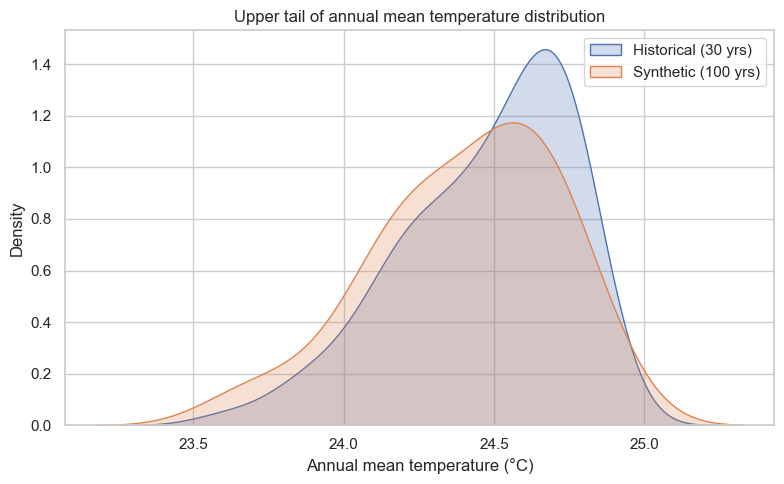

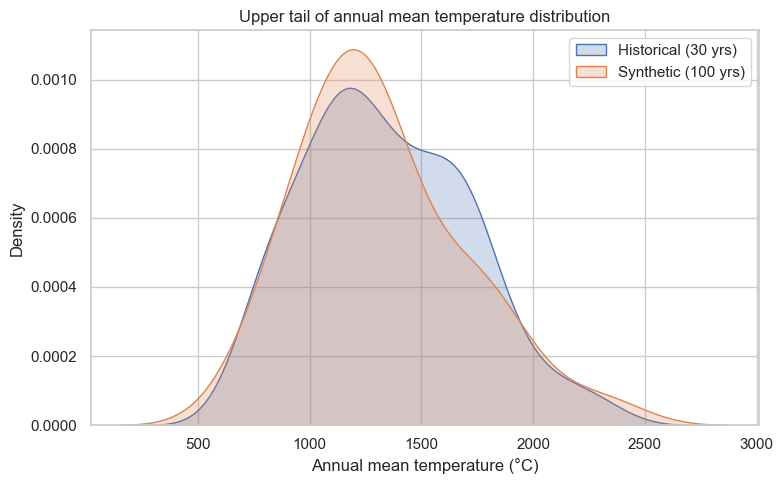

In [744]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

lat = 19.293583
lon = -71.252111

# Extract temperature time series at the point
point_tmean_100yrs = tmean_100yrs.sel(lat=lat, lon=lon, method="nearest").to_series()
point_tmean_hist = tmean.sel(lat=lat, lon=lon, method="nearest").to_series()

# Plot
plt.figure(figsize=(8, 5))
sns.kdeplot(point_tmean_100yrs.values, label="Historical (30 yrs)", fill=True)
sns.kdeplot(point_tmean_hist.values, label="Synthetic (100 yrs)", fill=True)
plt.xlabel("Annual mean temperature (°C)")
plt.ylabel("Density")
plt.title("Upper tail of annual mean temperature distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Extract temperature time series at the point
point_tmean_100yrs = ppt_100yrs.sel(lat=lat, lon=lon, method="nearest").to_series()
point_tmean_hist = ppt.sel(lat=lat, lon=lon, method="nearest").to_series()

# Plot
plt.figure(figsize=(8, 5))
sns.kdeplot(point_tmean_100yrs.values, label="Historical (30 yrs)", fill=True)
sns.kdeplot(point_tmean_hist.values, label="Synthetic (100 yrs)", fill=True)
plt.xlabel("Annual mean temperature (°C)")
plt.ylabel("Density")
plt.title("Upper tail of annual mean temperature distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# plotting the shift with climate change:

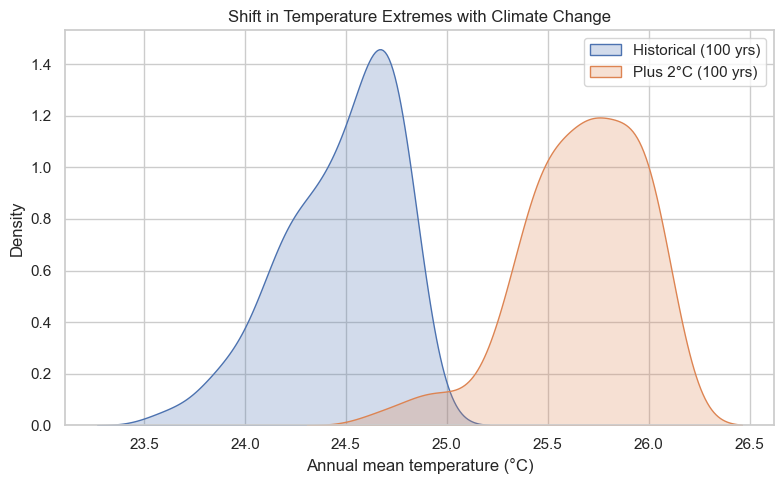

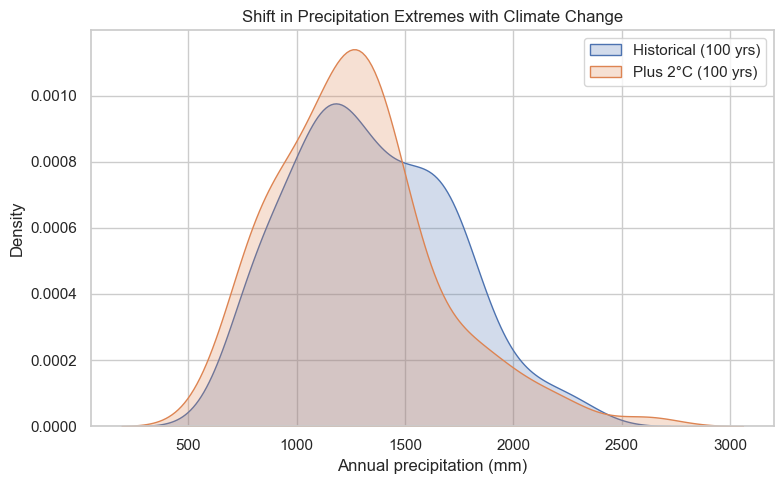

In [745]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the location
lat = 19.293583
lon = -71.252111

# Helper function to extract intensity time series at nearest centroid
def get_intensity_at_point(hazard, lat, lon):
    dists = np.sqrt((hazard.centroids.lat - lat)**2 + (hazard.centroids.lon - lon)**2)
    idx = dists.argmin()
    return hazard.intensity.toarray()[:, idx]

# Extract time series of temperature at the location
tmean_hist_vals = get_intensity_at_point(hazard_dict["historical"]["TM"], lat, lon)
tmean_future_vals = get_intensity_at_point(hazard_dict["plus2C"]["TM"], lat, lon)

# Plot KDE comparison
plt.figure(figsize=(8, 5))
sns.kdeplot(tmean_hist_vals, label="Historical (100 yrs)", fill=True)
sns.kdeplot(tmean_future_vals, label="Plus 2°C (100 yrs)", fill=True)
plt.xlabel("Annual mean temperature (°C)")
plt.ylabel("Density")
plt.title("Shift in Temperature Extremes with Climate Change")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Extract time series of precipitation at the location
ppt_hist_vals = get_intensity_at_point(hazard_dict["historical"]["PR"], lat, lon)
ppt_future_vals = get_intensity_at_point(hazard_dict["plus2C"]["PR"], lat, lon)

# Plot KDE comparison
plt.figure(figsize=(8, 5))
sns.kdeplot(ppt_hist_vals, label="Historical (100 yrs)", fill=True)
sns.kdeplot(ppt_future_vals, label="Plus 2°C (100 yrs)", fill=True)
plt.xlabel("Annual precipitation (mm)")
plt.ylabel("Density")
plt.title("Shift in Precipitation Extremes with Climate Change")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# let's add impact functions based on FAO thresholds:

In [922]:
# Define a helper function to extract local climate
def get_climate_at_point(tmean, ppt, lat, lon):
    t = tmean.sel(lat=lat, lon=lon, method="nearest").mean("year").values.item()
    p = ppt.sel(lat=lat, lon=lon, method="nearest").mean("year").values.item()
    return t, p

def make_trapezoidal_impact_func(haz_type, name, min_val, opt_min, opt_max, max_val, id_):
    impf = ImpactFunc()
    impf.haz_type = haz_type
    impf.id = id_
    impf.name = name
    impf.unit = "°C" if haz_type == "TM" else "mm"

    # Define the trapezoidal shape explicitly
    if haz_type == "TM":  # Vulnerability to high temperature
        intensity = np.array([opt_max, max_val, max_val + 5, max_val + 10])
        mdd = np.array([0.0, 0.5, 0.8, 1.0])  # only penalise beyond optimal max
    elif haz_type == "PR":  # Vulnerability to low precipitation
        intensity = np.array([min_val - 500, min_val - 200, opt_min, opt_min + 1])
        mdd = np.array([1.0, 0.8, 0.3, 0.0])  # only penalise below optimal

    paa = np.ones_like(mdd)
    mdr = mdd * paa

    impf.intensity = intensity
    impf.mdd = mdd
    impf.paa = paa
    impf.mdr = mdr

    impf.check()
    return impf


# Buffers for fallback
T_BUFFER = 5
P_BUFFER = 800

# Add lat/lon
agroforest_df["lat"] = agroforest_df.geometry.y
agroforest_df["lon"] = agroforest_df.geometry.x

# Initialize
impf_set = ImpactFuncSet()
species_to_temp_id = {}
species_to_prec_id = {}
fallback_ids = {}
counter = 1

# Loop through each row
for idx, row in agroforest_df.iterrows():
    species = row["species"]
    lat, lon = row["lat"], row["lon"]

    # Thresholds from EcoCrop
    tmin = row["TMIN"]
    tmax = row["TMAX"]
    t_opt_min = row.get("TOPMN", None)
    t_opt_max = row.get("TOPMX", None)

    rmin = row["RMIN"]
    rmax = row["RMAX"]
    r_opt_min = row.get("ROPMN", None)
    r_opt_max = row.get("ROPMX", None)

    # Skip if already created
    if species in species_to_temp_id and species in species_to_prec_id:
        continue

    # Fallback case
    if any(pd.isnull([tmin, tmax, rmin, rmax])):
        loc_key = (lat, lon)
        if loc_key in fallback_ids:
            temp_id, prec_id = fallback_ids[loc_key]
        else:
            t_loc, p_loc = get_climate_at_point(tmean, ppt, lat, lon)
            impf_temp = make_trapezoidal_impact_func("TM", f"fallback_{lat:.2f}_{lon:.2f}",
                                                     t_loc - T_BUFFER, t_loc - 1, t_loc + 1, t_loc + T_BUFFER, counter)
            impf_set.append(impf_temp)
            temp_id = counter
            counter += 1

            impf_prec = make_trapezoidal_impact_func("PR", f"fallback_{lat:.2f}_{lon:.2f}",
                                                     max(p_loc - P_BUFFER, 0), p_loc - 200, p_loc + 200, p_loc + P_BUFFER, counter)
            impf_set.append(impf_prec)
            prec_id = counter
            counter += 1

            fallback_ids[loc_key] = (temp_id, prec_id)

        species_to_temp_id[species] = temp_id
        species_to_prec_id[species] = prec_id

    else:
        # Use optimal if available, else fall back to min/max
        tmin_final = tmin
        tmax_final = tmax
        t_opt_min_final = t_opt_min if pd.notnull(t_opt_min) else tmin
        t_opt_max_final = t_opt_max if pd.notnull(t_opt_max) else tmax

        rmin_final = rmin
        rmax_final = rmax
        r_opt_min_final = r_opt_min if pd.notnull(r_opt_min) else rmin
        r_opt_max_final = r_opt_max if pd.notnull(r_opt_max) else rmax

        impf_temp = make_trapezoidal_impact_func("TM", species, tmin_final, t_opt_min_final, t_opt_max_final, tmax_final, counter)
        impf_set.append(impf_temp)
        species_to_temp_id[species] = counter
        counter += 1

        impf_prec = make_trapezoidal_impact_func("PR", species, rmin_final, r_opt_min_final, r_opt_max_final, rmax_final, counter)
        impf_set.append(impf_prec)
        species_to_prec_id[species] = counter
        counter += 1

# Assign impact function IDs
agroforest_df["impf_TM"] = agroforest_df["species"].map(species_to_temp_id)
agroforest_df["impf_PR"] = agroforest_df["species"].map(species_to_prec_id)


In [914]:
agroforest_df

,species,n_trees,height_m,type,cover_ratio,role,plot_size_m2,forest_cover,canopy_height,land_use_class,...,geometry,adjusted_cover_ratio,adjusted_cover_area_m2,species_based_cover_area_m2,estimated_forest_cover_area_m2,expected_forest_area_m2,shading_m2,plot_index,lat,lon
0,Inga fagifolia single,43,20,1st tree,20.0,upper canopy,4184,93.000000,19.857143,Tree cover,...,POINT (-71.25211 19.29358),860.0,35982.40,35982.40,3891.120000,3891.120000,229.273625,0,19.293583,-71.252111
1,Mangifera indica single,22,20,1st tree,5.0,upper canopy,4184,93.000000,19.857143,Tree cover,...,POINT (-71.25211 19.29358),110.0,4602.40,4602.40,3891.120000,3891.120000,29.325696,0,19.293583,-71.252111
2,Roystonea hispaniolana single,14,1,Herb,0.5,understory,4184,93.000000,19.857143,Tree cover,...,POINT (-71.25211 19.29358),7.0,292.88,292.88,3891.120000,3891.120000,1.866181,0,19.293583,-71.252111
3,Didymopanax morototoni single,5,20,1st tree,1.0,upper canopy,4184,93.000000,19.857143,Tree cover,...,POINT (-71.25211 19.29358),5.0,209.20,209.20,3891.120000,3891.120000,1.332986,0,19.293583,-71.252111
4,Senna spectabilis single,2,20,1st tree,0.5,upper canopy,4184,93.000000,19.857143,Tree cover,...,POINT (-71.25211 19.29358),1.0,41.84,41.84,3891.120000,3891.120000,0.266597,0,19.293583,-71.252111
5,Musa × paradisiaca,52,10,2nd tree,35.0,mid canopy,4184,93.000000,19.857143,Tree cover,...,POINT (-71.25211 19.29358),1820.0,76148.80,76148.80,3891.120000,3891.120000,485.206975,0,19.293583,-71.252111
6,Theobroma cacao,70,4,Shrub,10.0,understory,4184,93.000000,19.857143,Tree cover,...,POINT (-71.25211 19.29358),700.0,29288.00,29288.00,3891.120000,3891.120000,186.618067,0,19.293583,-71.252111
7,Citrus × sinensis single,11,10,2nd tree,2.5,mid canopy,4184,93.000000,19.857143,Tree cover,...,POINT (-71.25211 19.29358),27.5,1150.60,1150.60,3891.120000,3891.120000,7.331424,0,19.293583,-71.252111
8,Citrus × aurantium single,10,10,2nd tree,2.5,mid canopy,4184,93.000000,19.857143,Tree cover,...,POINT (-71.25211 19.29358),25.0,1046.00,1046.00,3891.120000,3891.120000,6.664931,0,19.293583,-71.252111
9,Pimenta racemosa single,8,10,2nd tree,2.0,mid canopy,4184,93.000000,19.857143,Tree cover,...,POINT (-71.25211 19.29358),16.0,669.44,669.44,3891.120000,3891.120000,4.265556,0,19.293583,-71.252111


📊 Temperature impact function for Theobroma cacao
📊 Precipitation impact function for Theobroma cacao


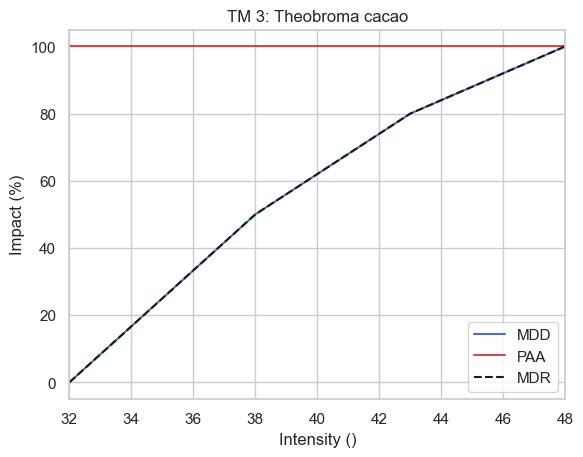

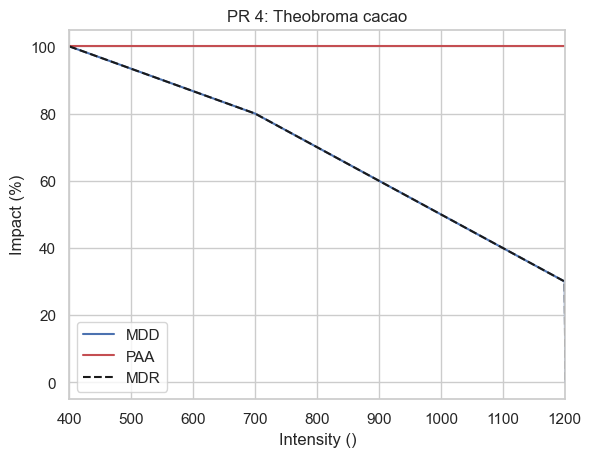

In [923]:
# Define cacao species name as used in your data
cacao_species = "Theobroma cacao"  # adjust if your naming is different

# Get the impact function IDs
cacao_temp_id = species_to_temp_id.get(cacao_species)
cacao_prec_id = species_to_prec_id.get(cacao_species)

# Plot temperature impact function
if cacao_temp_id:
    print(f"📊 Temperature impact function for {cacao_species}")
    impf_set.get_func()['TM'][cacao_temp_id].plot()
else:
    print("⚠️ Temperature impact function not found for cacao.")

# Plot precipitation impact function
if cacao_prec_id:
    print(f"📊 Precipitation impact function for {cacao_species}")
    impf_set.get_func()['PR'][cacao_prec_id].plot()
else:
    print("⚠️ Precipitation impact function not found for cacao.")


In [739]:
for scenario in hazard_dict:
    for haz in hazard_dict[scenario]:
        hazard_dict[scenario][haz].event_id = np.array(hazard_dict[scenario][haz].event_id)

# impact calculation:

In [925]:
# Compute impact
from climada.engine import ImpactCalc
from climada.entity import Exposures
agroforest_df['value'] =  agroforest_df["shading_m2"]


exp= Exposures(data=agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))])
impact_results = {
    scenario: {
        haz_type: ImpactCalc(exp, impf_set, hazard).impact(save_mat=True)
        for haz_type, hazard in hazards.items()
    }
    for scenario, hazards in hazard_dict.items()
}

2025-06-06 09:57:22,228 - climada.hazard.base - WARNING - Impact function id=10 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-06-06 09:57:22,231 - climada.hazard.base - WARNING - Impact function id=12 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-06-06 09:57:22,235 - climada.hazard.base - WARNING - Impact function id=14 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-06-06 09:57:22,238 - climada.hazard.base - WARNING - Impact function id=16 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2025-06-06 09:57:22,240 - climada.hazard.base - WARNING - Impact function id=18 has mdr(0) != 0.The mean damage ratio mu

In [926]:
impact_results['historical']['TM'].tot_value

2025-06-06 09:57:29,025 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


41.33627209473183

# Impacts:

2025-06-06 10:00:24,125 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


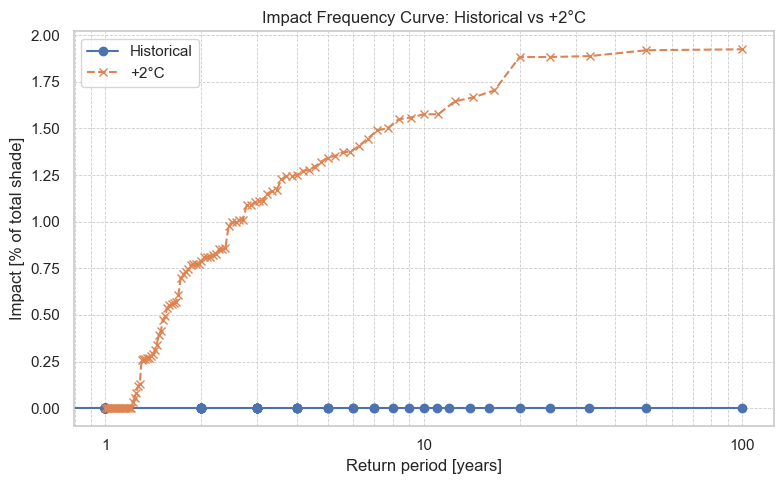

In [935]:
import matplotlib.pyplot as plt

# Get frequency curves
freq_hist = impact_results['historical']['TM'].calc_freq_curve()
freq_sim = impact_results['plus2C']['TM'].calc_freq_curve()

# Total value (same base for percentage calculation)
base_tot_value = impact_results['plus2C']['TM'].tot_value

# Plot
plt.figure(figsize=(8, 5))
plt.plot(freq_hist.return_per.astype('int'), 100 * freq_hist.impact / base_tot_value,
         label="Historical", marker='o', linestyle='-')
plt.plot(freq_sim.return_per, 100 * freq_sim.impact / base_tot_value,
         label="+2°C", marker='x', linestyle='--')

plt.xlabel("Return period [years]")
plt.ylabel("Impact [% of total shade]")
plt.title("Impact Frequency Curve: Historical vs +2°C")
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.6)
plt.xscale("log")
plt.xticks([1, 10, 100], labels=["1", "10", "100"])

plt.tight_layout()
plt.show()


2025-06-06 10:00:34,121 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


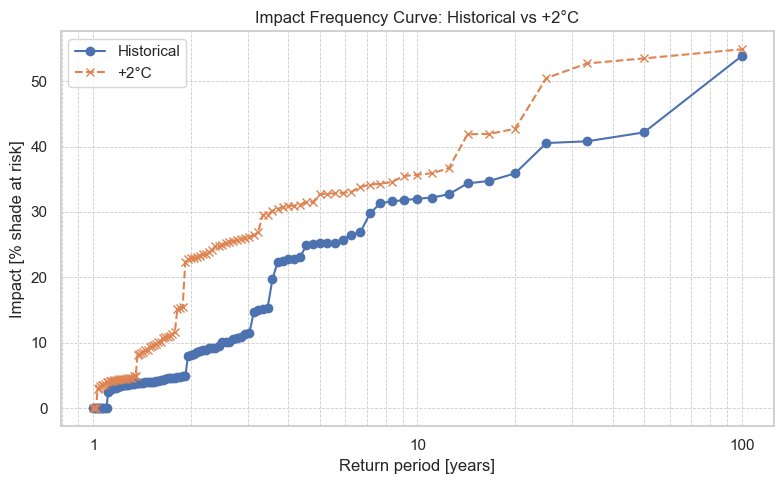

In [936]:
import matplotlib.pyplot as plt

# Get frequency curves
freq_hist = impact_results['historical']['PR'].calc_freq_curve()
freq_sim = impact_results['plus2C']['PR'].calc_freq_curve()

# Total value for normalisation
base_tot_value = impact_results['plus2C']['PR'].tot_value

# Plot
plt.figure(figsize=(8, 5))
plt.plot(freq_hist.return_per, 100 * freq_hist.impact / base_tot_value,
         label="Historical", marker='o', linestyle='-')
plt.plot(freq_sim.return_per, 100 * freq_sim.impact / base_tot_value,
         label="+2°C", marker='x', linestyle='--')

plt.xlabel("Return period [years]")
plt.ylabel("Impact [% shade at risk]")
plt.title("Impact Frequency Curve: Historical vs +2°C")
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.6)
plt.xscale("log")
plt.xticks([1, 10, 100], labels=["1", "10", "100"])

plt.tight_layout()
plt.show()


# Let's check which species are most at risk:

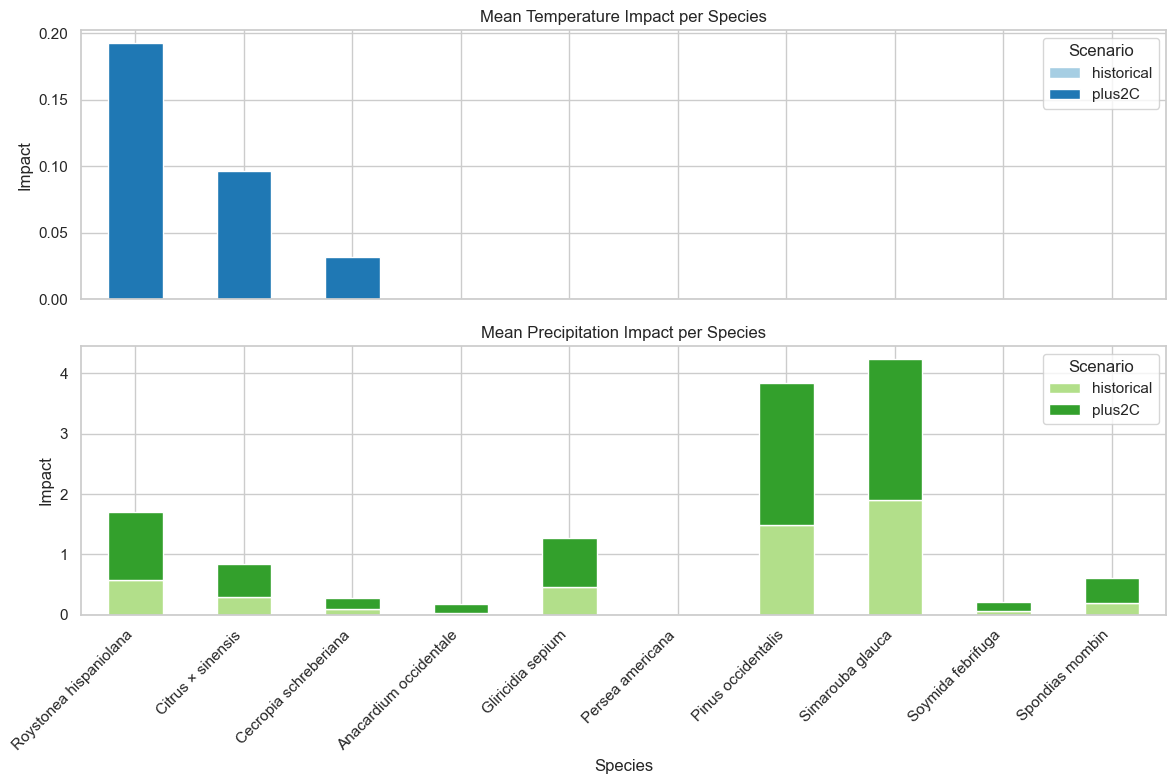

In [943]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define scenarios and hazards
scenarios = ["historical", "plus2C"]
hazards = ["TM", "PR"]

# Filter species (only 1st and 2nd tree layer for a specific plot)
species_names = agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
]["species"].values

# Gather impact data
results = []

for scenario in scenarios:
    for hazard in hazards:
        imp_mat = impact_results[scenario][hazard].imp_mat  # (time, species)
        mean_impact = imp_mat.mean(axis=0)

        df = pd.DataFrame({
            "species": species_names,
            "mean_impact": np.array(mean_impact).flatten(),
            "hazard": hazard,
            "scenario": scenario
        })
        results.append(df)

# Combine into one DataFrame
impact_df = pd.concat(results, ignore_index=True)

# Pivot to a tidy format for each hazard
impact_tm = impact_df[impact_df["hazard"] == "TM"].pivot(index="species", columns="scenario", values="mean_impact").fillna(0)
impact_pr = impact_df[impact_df["hazard"] == "PR"].pivot(index="species", columns="scenario", values="mean_impact").fillna(0)

# Sort by +2C impact consistently
species_order = impact_tm["plus2C"].sort_values(ascending=False).index
impact_tm = impact_tm.loc[species_order]
impact_pr = impact_pr.loc[species_order]

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Temperature impact
impact_tm.plot(kind="bar", stacked=True, ax=axs[0], color=["#a6cee3", "#1f78b4"])
axs[0].set_title("Mean Temperature Impact per Species")
axs[0].set_ylabel("Impact")
axs[0].legend(title="Scenario")

# Precipitation impact
impact_pr.plot(kind="bar", stacked=True, ax=axs[1], color=["#b2df8a", "#33a02c"])
axs[1].set_title("Mean Precipitation Impact per Species")
axs[1].set_ylabel("Impact")
axs[1].set_xlabel("Species")
axs[1].legend(title="Scenario")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
agroforest_df.value

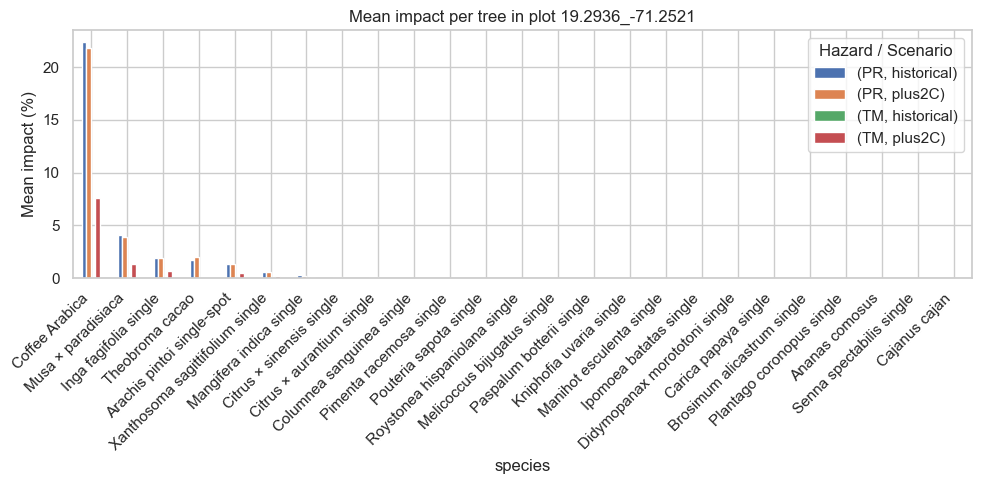

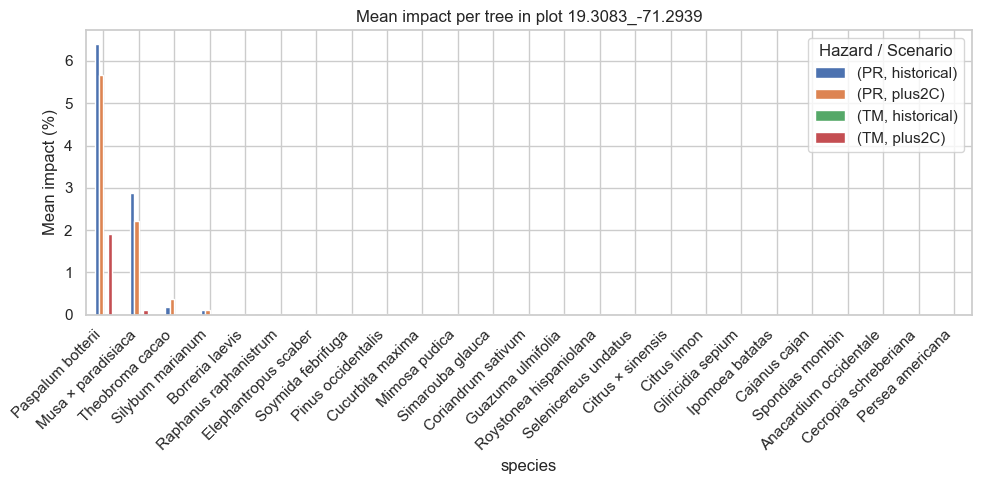

In [769]:
import pandas as pd
import matplotlib.pyplot as plt

scenarios = ["historical", "plus2C"]
hazards = ["TM", "PR"]

# Step 1: Create unique plot ID based on rounded lat/lon
agroforest_df["plot_id"] = agroforest_df[["lat", "lon"]].round(4).astype(str).agg("_".join, axis=1)

# Step 2: Build full dataframe with impacts per tree
records = []
for scenario in scenarios:
    for hazard in hazards:
        imp_mat = impact_results[scenario][hazard].imp_mat  # shape: (years, trees)
        mean_impact_per_tree = imp_mat.mean(axis=0).A1  # flatten from matrix

        for i, val in enumerate(mean_impact_per_tree):
            records.append({
                "plot_id": agroforest_df.iloc[i]["plot_id"],
                "species": agroforest_df.iloc[i]["species"],
                "lat": agroforest_df.iloc[i]["lat"],
                "lon": agroforest_df.iloc[i]["lon"],
                "hazard": hazard,
                "scenario": scenario,
                "impact": val,
                "shade_value": agroforest_df.iloc[i].get("shade_value", None)
            })

impact_long_df = pd.DataFrame.from_records(records)

# Step 3: Plot per plot_id
for plot_id, plot_df in impact_long_df.groupby("plot_id"):
    fig, ax = plt.subplots(figsize=(10, 5))

    pivot = plot_df.pivot_table(index="species", columns=["hazard", "scenario"], values="impact").fillna(0)

    # Sort by total mean impact
    pivot["total"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("total", ascending=False)
    pivot.drop(columns="total", inplace=True)

    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Mean impact per tree in plot {plot_id}")
    ax.set_ylabel("Mean impact (%)")
    ax.legend(title="Hazard / Scenario")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()



In [767]:
# how to include uncertainties: impact function, exposures, adaptation

0       8.600
1       1.100
2       0.070
3       0.050
4       0.010
5      18.200
6       7.000
7       0.275
8       0.250
9       0.160
10      0.090
11      0.050
12      0.050
13    100.800
14      0.200
15      0.160
16      0.050
17      0.050
18      6.000
19      2.600
20      0.050
21      0.050
22      0.020
23      0.050
24      0.020
25      0.030
26      0.030
27      0.020
28      0.025
29      0.005
30     11.000
31      0.055
32      0.060
33      0.015
34      0.040
35      0.020
36      0.020
37      0.020
38     25.000
39      1.000
40      0.025
41      0.400
42      0.100
43      0.100
44      0.100
45      0.100
46      0.100
47      0.100
48      0.100
49      0.100
Name: value, dtype: float64